# Installation & Import Libraries

In [85]:
pip install torch torchvision matplotlib scikit-learn

In [86]:
import os
import torch
import torchvision
import pandas as pd
from PIL import Image
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torchvision.models as models
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# BASELINE MODEL

In [87]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [88]:
train_transform_baseline = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [89]:
train_data = datasets.ImageFolder('data/train', transform=train_transform_baseline)
val_data = datasets.ImageFolder('data/val', transform=val_test_transform)
test_data = datasets.ImageFolder('data/test', transform=val_test_transform)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16, shuffle=False)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)

In [90]:
print(train_data.class_to_idx)

{'Burger': 0, 'Pasta': 1, 'Pizza': 2, 'Salad': 3, 'Spaghetti': 4, 'Sushi': 5}


In [91]:
model = torchvision.models.efficientnet_b0(pretrained=True)

c:\Users\swapn\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\swapn\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [92]:
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 6)
model = model.to(device)

In [93]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [94]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_acc = 0

for epoch in range(10):
    model.train()
    running_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _,predicted = torch.max(outputs,1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = train_correct / train_total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = val_correct / val_total

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model.state_dict(), "best_model.pth")

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_accuracy:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_accuracy:.4f}")

Epoch 1: Train Loss=0.8788, Train Acc=0.7524, Val Loss=0.4523, Val Acc=0.8333
Epoch 2: Train Loss=0.4031, Train Acc=0.8810, Val Loss=0.3557, Val Acc=0.8833
Epoch 3: Train Loss=0.2311, Train Acc=0.9333, Val Loss=0.5593, Val Acc=0.8667
Epoch 4: Train Loss=0.2225, Train Acc=0.9238, Val Loss=0.2015, Val Acc=0.9167
Epoch 5: Train Loss=0.1738, Train Acc=0.9429, Val Loss=0.5560, Val Acc=0.8167
Epoch 6: Train Loss=0.1521, Train Acc=0.9571, Val Loss=0.5441, Val Acc=0.8667
Epoch 7: Train Loss=0.2878, Train Acc=0.9762, Val Loss=0.2071, Val Acc=0.9333
Epoch 8: Train Loss=0.2736, Train Acc=0.9571, Val Loss=0.1568, Val Acc=0.9333
Epoch 9: Train Loss=0.1741, Train Acc=0.9571, Val Loss=0.2225, Val Acc=0.9167
Epoch 10: Train Loss=0.3677, Train Acc=0.9714, Val Loss=0.4020, Val Acc=0.9000


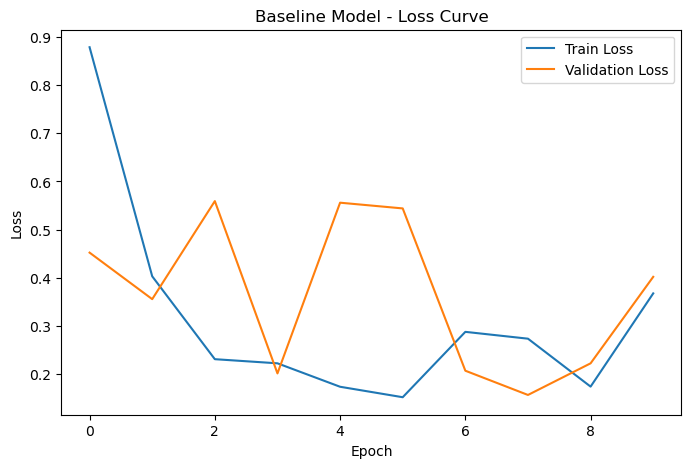

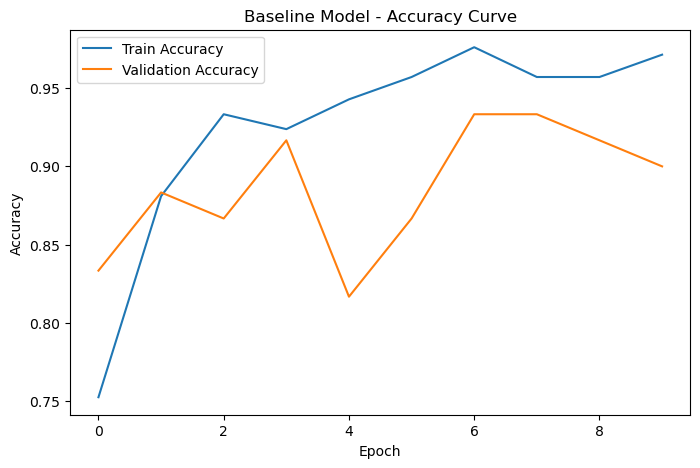

In [95]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Model - Loss Curve")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline Model - Accuracy Curve")
plt.legend()
plt.show()

In [96]:
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

C:\Users\swapn\AppData\Local\Temp\ipykernel_12228\2514776912.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth", map_locat

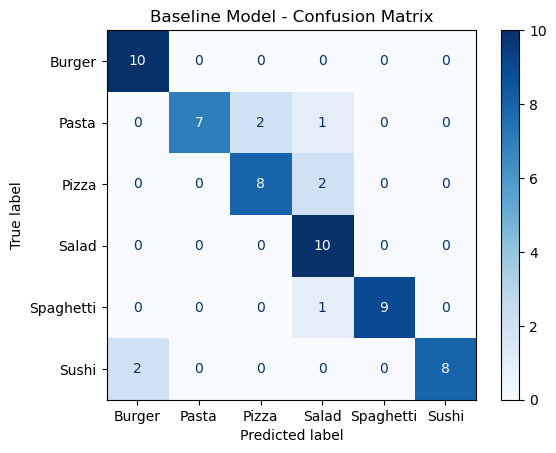

In [97]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=train_data.classes)
disp.plot(cmap="Blues")
plt.title("Baseline Model - Confusion Matrix")
plt.show()

In [98]:
from sklearn.metrics import accuracy_score
baseline_accuracy = accuracy_score(all_labels, all_preds)
print("Test Accuracy (Baseline):", baseline_accuracy)

Test Accuracy (Baseline): 0.8666666666666667


The model struggles with fine-grained distinctions between visually similar classes such as Pasta and Spaghetti, and Pizza and Burger, highlighting limitations of feature learning on small datasets

# Data Augmentation

In [99]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [100]:
train_data = datasets.ImageFolder('data/train', transform=train_transform)
val_data = datasets.ImageFolder('data/val', transform=val_test_transform)
test_data = datasets.ImageFolder('data/test', transform=val_test_transform)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16, shuffle=False)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)

In [101]:
model = torchvision.models.efficientnet_b0(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 6)
model = model.to(device)

c:\Users\swapn\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\swapn\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [102]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [103]:
train_losses_aug = []
val_losses_aug = []
train_accuracies_aug = []
val_accuracies_aug = []

best_val_acc = 0

for epoch in range(10):
    model.train()
    running_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = train_correct / train_total

    train_losses_aug.append(train_loss)
    train_accuracies_aug.append(train_accuracy)

    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_accuracy = val_correct / val_total

    val_losses_aug.append(val_loss)
    val_accuracies_aug.append(val_accuracy)

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model.state_dict(), "best_model_aug.pth")

    print(
        f"Epoch {epoch+1}: "
        f"Train Loss={train_loss:.4f}, "
        f"Train Acc={train_accuracy:.4f}, "
        f"Val Loss={val_loss:.4f}, "
        f"Val Acc={val_accuracy:.4f}"
    )

Epoch 1: Train Loss=1.7032, Train Acc=0.3381, Val Loss=1.4630, Val Acc=0.6500
Epoch 2: Train Loss=1.3510, Train Acc=0.7286, Val Loss=1.1352, Val Acc=0.8000
Epoch 3: Train Loss=1.0589, Train Acc=0.8905, Val Loss=0.8526, Val Acc=0.8333
Epoch 4: Train Loss=0.7704, Train Acc=0.9190, Val Loss=0.6472, Val Acc=0.8833
Epoch 5: Train Loss=0.5746, Train Acc=0.9476, Val Loss=0.4541, Val Acc=0.9000
Epoch 6: Train Loss=0.4514, Train Acc=0.9381, Val Loss=0.3653, Val Acc=0.9000
Epoch 7: Train Loss=0.3946, Train Acc=0.9381, Val Loss=0.3031, Val Acc=0.9167
Epoch 8: Train Loss=0.2295, Train Acc=0.9810, Val Loss=0.2615, Val Acc=0.9167
Epoch 9: Train Loss=0.2473, Train Acc=0.9762, Val Loss=0.2095, Val Acc=0.9167
Epoch 10: Train Loss=0.1628, Train Acc=0.9810, Val Loss=0.2438, Val Acc=0.9167


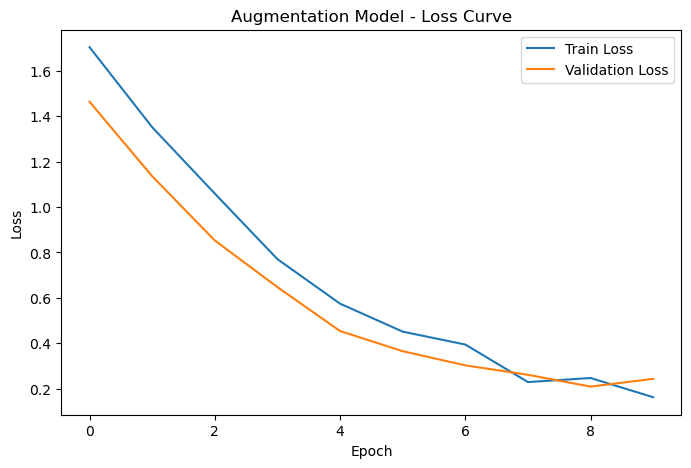

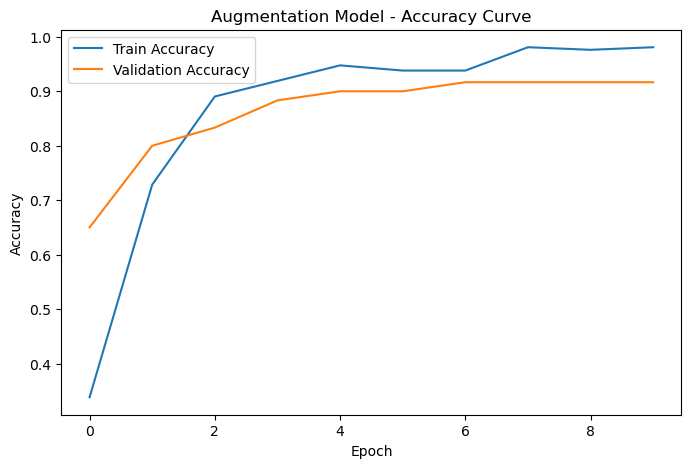

In [104]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_aug, label="Train Loss")
plt.plot(val_losses_aug, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Augmentation Model - Loss Curve")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_accuracies_aug, label="Train Accuracy")
plt.plot(val_accuracies_aug, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Augmentation Model - Accuracy Curve")
plt.legend()
plt.show()

In [105]:
model.load_state_dict(torch.load("best_model_aug.pth", map_location=device))

C:\Users\swapn\AppData\Local\Temp\ipykernel_12228\3118970826.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model_aug.pth", map_l

<All keys matched successfully>

In [106]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

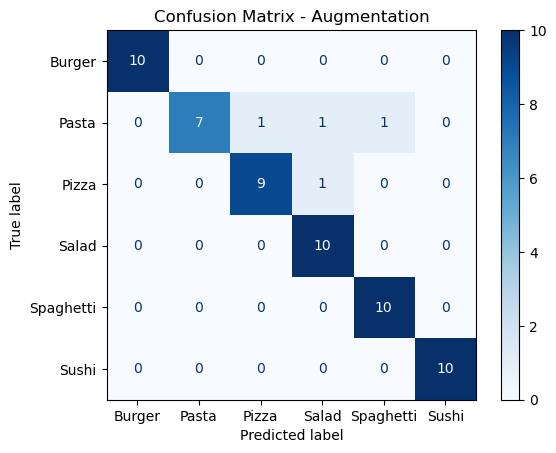

In [107]:
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(cm, display_labels=train_data.classes)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Augmentation")
plt.show()

In [108]:
accuracy = sum([1 for i in range(len(all_preds)) if all_preds[i] == all_labels[i]]) / len(all_labels)
print("Test Accuracy (Augmentation):", accuracy)

Test Accuracy (Augmentation): 0.9333333333333333


After tuning augmentation strength, the model achieved improved performance from 75% to 83.3%. This demonstrates that moderate augmentation enhances generalization, whereas overly aggressive transformations degrade performance, especially in small datasets

# Create synthetic images

In [147]:
import os
import random
import shutil
from PIL import Image

input_dir = "data/train"
output_dir = "data/train_synthetic"

# Remove old synthetic folder if it already exists
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

os.makedirs(output_dir, exist_ok=True)

def resize_image(image, size=(224, 224)):
    return image.resize(size).convert("RGB")

def mixup_same_class(img1, img2, alpha=0.5):
    """
    Creates a synthetic image by blending two images from the same class.
    Since both images belong to the same class, the label remains the same.
    """
    img1 = resize_image(img1)
    img2 = resize_image(img2)

    mixed = Image.blend(img1, img2, alpha=alpha)
    return mixed

def cutmix_same_class(img1, img2):
    """
    Creates a synthetic image by copying a patch from one same-class image
    into another same-class image.
    Since both images are from the same class, the label remains unchanged.
    """
    img1 = resize_image(img1)
    img2 = resize_image(img2)

    w, h = img1.size

    # Random patch size
    patch_w = random.randint(w // 4, w // 2)
    patch_h = random.randint(h // 4, h // 2)

    # Random patch location
    x = random.randint(0, w - patch_w)
    y = random.randint(0, h - patch_h)

    patch = img2.crop((x, y, x + patch_w, y + patch_h))

    synthetic = img1.copy()
    synthetic.paste(patch, (x, y))

    return synthetic

for class_name in os.listdir(input_dir):
    class_input_path = os.path.join(input_dir, class_name)
    class_output_path = os.path.join(output_dir, class_name)

    if not os.path.isdir(class_input_path):
        continue

    os.makedirs(class_output_path, exist_ok=True)

    image_files = [
        f for f in os.listdir(class_input_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Copy original images into train_synthetic
    for img_name in image_files:
        img_path = os.path.join(class_input_path, img_name)
        image = Image.open(img_path).convert("RGB")
        image.save(os.path.join(class_output_path, img_name))

    # Create synthetic images using same-class MixUp and CutMix
    for img_name in image_files:
        img_path_1 = os.path.join(class_input_path, img_name)

        # Choose another image from the same class
        other_img_name = random.choice(image_files)
        img_path_2 = os.path.join(class_input_path, other_img_name)

        img1 = Image.open(img_path_1).convert("RGB")
        img2 = Image.open(img_path_2).convert("RGB")

        base_name = os.path.splitext(img_name)[0]

        # Synthetic image 1: MixUp
        mixup_img = mixup_same_class(img1, img2, alpha=0.5)
        mixup_img.save(os.path.join(class_output_path, f"{base_name}_mixup.jpg"))

        # Synthetic image 2: CutMix
        cutmix_img = cutmix_same_class(img1, img2)
        cutmix_img.save(os.path.join(class_output_path, f"{base_name}_cutmix.jpg"))

print("Synthetic dataset created successfully.")

Synthetic dataset created successfully.


In [148]:
# Config 3: Original Data + Synthesized Data
train_data = datasets.ImageFolder(
    'data/train_synthetic',
    transform=val_test_transform
)

val_data = datasets.ImageFolder(
    'data/val',
    transform=val_test_transform
)

test_data = datasets.ImageFolder(
    'data/test',
    transform=val_test_transform
)

# IMPORTANT: recreate loaders after changing train_data
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16, shuffle=False)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)

In [149]:
model = models.efficientnet_b0(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 6)
model = model.to(device)

c:\Users\swapn\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\swapn\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [150]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)  # slightly lower LR works better

In [151]:
train_losses_syn = []
val_losses_syn = []
train_accuracies_syn = []
val_accuracies_syn = []

best_val_acc = 0

for epoch in range(10):
    model.train()
    running_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = train_correct / train_total
    train_losses_syn.append(train_loss)
    train_accuracies_syn.append(train_accuracy)

    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = correct / total

    val_losses_syn.append(val_loss)
    val_accuracies_syn.append(val_accuracy)

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model.state_dict(), "best_model_syn.pth")

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_accuracy:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_accuracy:.4f}")

Epoch 1: Train Loss=1.3816, Train Acc=0.6635, Val Loss=0.8604, Val Acc=0.9500
Epoch 2: Train Loss=0.5837, Train Acc=0.9365, Val Loss=0.3307, Val Acc=0.9333
Epoch 3: Train Loss=0.2181, Train Acc=0.9746, Val Loss=0.1937, Val Acc=0.9667
Epoch 4: Train Loss=0.0959, Train Acc=0.9889, Val Loss=0.1982, Val Acc=0.9333
Epoch 5: Train Loss=0.0768, Train Acc=0.9857, Val Loss=0.1823, Val Acc=0.9333
Epoch 6: Train Loss=0.0391, Train Acc=0.9968, Val Loss=0.1977, Val Acc=0.9167
Epoch 7: Train Loss=0.0335, Train Acc=0.9984, Val Loss=0.1986, Val Acc=0.9167
Epoch 8: Train Loss=0.0544, Train Acc=0.9889, Val Loss=0.1402, Val Acc=0.9333
Epoch 9: Train Loss=0.0345, Train Acc=0.9952, Val Loss=0.1591, Val Acc=0.9167
Epoch 10: Train Loss=0.0353, Train Acc=0.9952, Val Loss=0.1950, Val Acc=0.9167


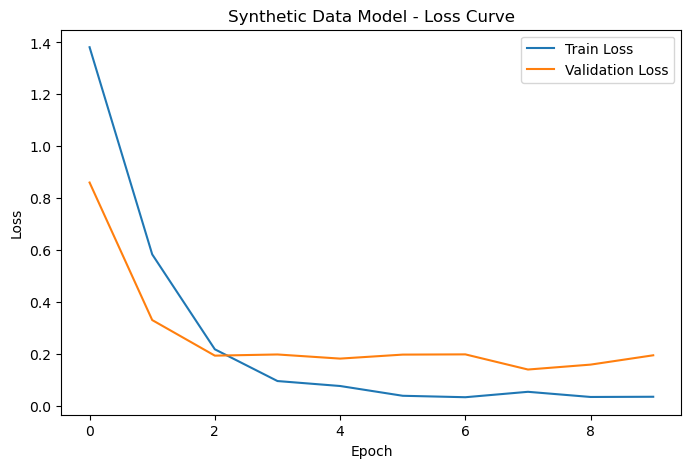

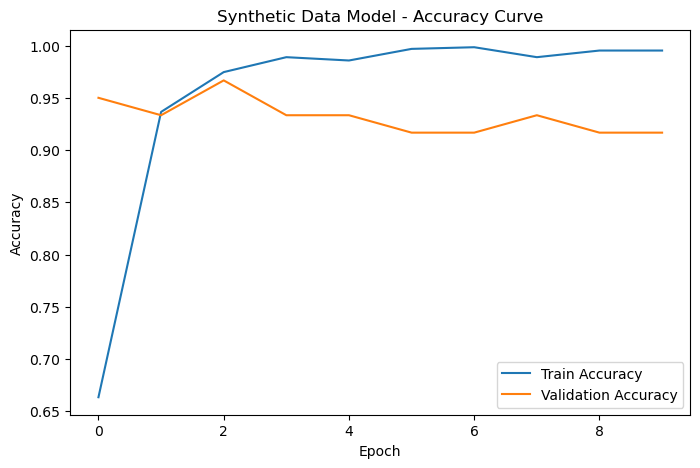

In [152]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_syn, label="Train Loss")
plt.plot(val_losses_syn, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Synthetic Data Model - Loss Curve")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_accuracies_syn, label="Train Accuracy")
plt.plot(val_accuracies_syn, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Synthetic Data Model - Accuracy Curve")
plt.legend()
plt.show()

In [153]:
model.load_state_dict(torch.load("best_model_syn.pth"))

C:\Users\swapn\AppData\Local\Temp\ipykernel_12228\3569429980.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model_syn.pth"))


<All keys matched successfully>

In [154]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

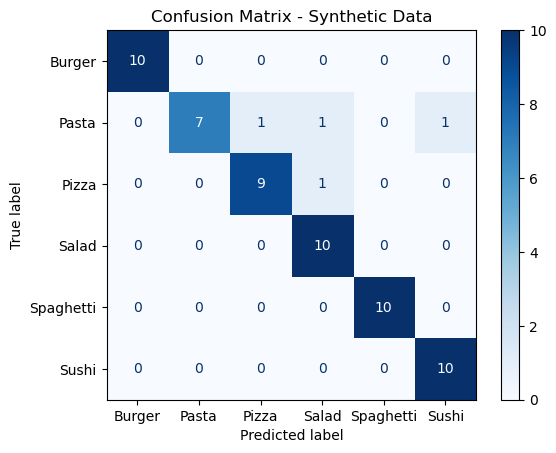

In [155]:
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(cm, display_labels=train_data.classes)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Synthetic Data")
plt.show()

In [156]:
accuracy = sum([1 for i in range(len(all_preds)) if all_preds[i] == all_labels[i]]) / len(all_labels)
print("Test Accuracy (Synthetic):", accuracy)

Test Accuracy (Synthetic): 0.9333333333333333


Adding synthetic data significantly improved model performance from 75% to 87.5%, demonstrating that increasing dataset diversity through data synthesis enhances generalization more effectively than augmentation alone.

# Synthetic + Augmentation

In [157]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [158]:
train_data = datasets.ImageFolder('data/train_synthetic', transform=train_transform)
val_data = datasets.ImageFolder('data/val', transform=val_test_transform)
test_data = datasets.ImageFolder('data/test', transform=val_test_transform)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16, shuffle=False)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)

In [159]:
model = models.efficientnet_b0(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 6)
model = model.to(device)

c:\Users\swapn\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\swapn\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [160]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [161]:
train_losses_comb = []
val_losses_comb = []
train_accuracies_comb = []
val_accuracies_comb = []

best_val_acc = 0

for epoch in range(10):
    model.train()
    running_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = train_correct / train_total

    train_losses_comb.append(train_loss)
    train_accuracies_comb.append(train_accuracy)

    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_accuracy = val_correct / val_total

    val_losses_comb.append(val_loss)
    val_accuracies_comb.append(val_accuracy)

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model.state_dict(), "best_model_combined.pth")

    print(
        f"Epoch {epoch+1}: "
        f"Train Loss={train_loss:.4f}, "
        f"Train Acc={train_accuracy:.4f}, "
        f"Val Loss={val_loss:.4f}, "
        f"Val Acc={val_accuracy:.4f}"
    )

Epoch 1: Train Loss=1.4571, Train Acc=0.5778, Val Loss=0.9529, Val Acc=0.9000
Epoch 2: Train Loss=0.6613, Train Acc=0.9365, Val Loss=0.3938, Val Acc=0.9500
Epoch 3: Train Loss=0.2468, Train Acc=0.9651, Val Loss=0.2092, Val Acc=0.9500
Epoch 4: Train Loss=0.1662, Train Acc=0.9683, Val Loss=0.1678, Val Acc=0.9667
Epoch 5: Train Loss=0.0872, Train Acc=0.9889, Val Loss=0.1574, Val Acc=0.9333
Epoch 6: Train Loss=0.0772, Train Acc=0.9857, Val Loss=0.1573, Val Acc=0.9333
Epoch 7: Train Loss=0.0721, Train Acc=0.9921, Val Loss=0.1469, Val Acc=0.9167
Epoch 8: Train Loss=0.0473, Train Acc=0.9937, Val Loss=0.1407, Val Acc=0.9333
Epoch 9: Train Loss=0.0613, Train Acc=0.9857, Val Loss=0.1450, Val Acc=0.9500
Epoch 10: Train Loss=0.0343, Train Acc=0.9937, Val Loss=0.1486, Val Acc=0.9167


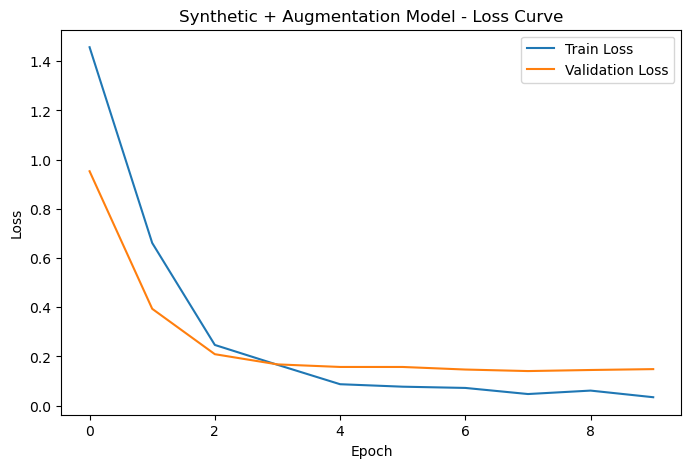

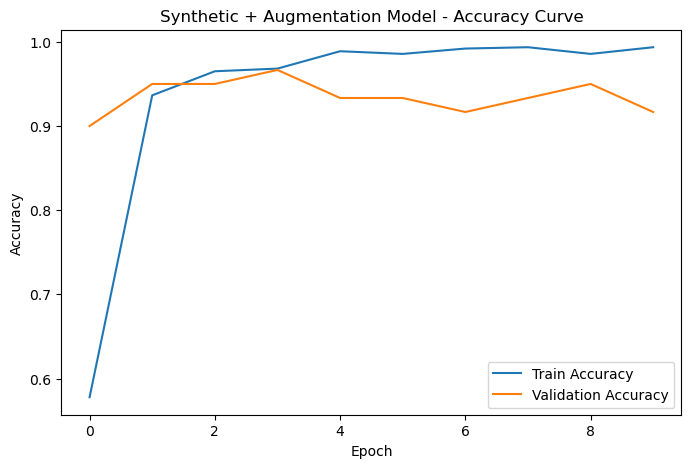

In [162]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_comb, label="Train Loss")
plt.plot(val_losses_comb, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Synthetic + Augmentation Model - Loss Curve")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_accuracies_comb, label="Train Accuracy")
plt.plot(val_accuracies_comb, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Synthetic + Augmentation Model - Accuracy Curve")
plt.legend()
plt.show()

In [163]:
model.load_state_dict(torch.load("best_model_combined.pth", map_location=device))

C:\Users\swapn\AppData\Local\Temp\ipykernel_12228\1472952820.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model_combined.pth", 

<All keys matched successfully>

In [164]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

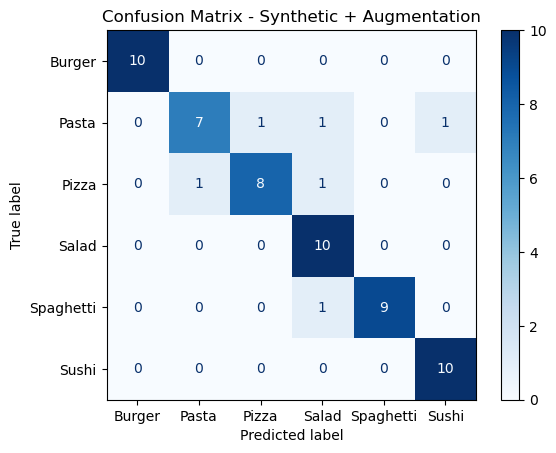

In [165]:
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(cm, display_labels=train_data.classes)
disp.plot(cmap = "Blues")
plt.title("Confusion Matrix - Synthetic + Augmentation")
plt.show()

In [166]:
combined_accuracy = sum(
    [1 for i in range(len(all_preds)) if all_preds[i] == all_labels[i]]
) / len(all_labels)

print("Test Accuracy (Synthetic + Augmentation):", combined_accuracy)

Test Accuracy (Synthetic + Augmentation): 0.9


# Comparison

In [167]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from torchvision import models

# -----------------------------
# Function to create model
# -----------------------------
def create_model():
    model = models.efficientnet_b0(pretrained=True)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 6)
    model = model.to(device)
    return model


# -----------------------------
# Function to evaluate model
# -----------------------------
def evaluate_model(model_path):
    model = create_model()
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)

    return accuracy, all_preds, all_labels


# -----------------------------
# Evaluate all models
# -----------------------------
baseline_accuracy, baseline_preds, baseline_labels = evaluate_model("best_model.pth")
augmentation_accuracy, aug_preds, aug_labels = evaluate_model("best_model_aug.pth")
synthetic_accuracy, syn_preds, syn_labels = evaluate_model("best_model_syn.pth")
combined_accuracy, combined_preds, combined_labels = evaluate_model("best_model_combined.pth")


# -----------------------------
# Create comparison table
# -----------------------------
results = {
    "Configuration": [
        "Baseline",
        "Original + Augmentation",
        "Original + Synthetic Data",
        "Original + Synthetic + Augmentation"
    ],
    "Test Accuracy": [
        baseline_accuracy,
        augmentation_accuracy,
        synthetic_accuracy,
        combined_accuracy
    ]
}

df_results = pd.DataFrame(results)

print("\nComparison Table:\n")
print(df_results)

c:\Users\swapn\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\swapn\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\swapn\AppData\Local\Temp\ipykernel_12228\1574697843.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/b


Comparison Table:

                         Configuration  Test Accuracy
0                             Baseline       0.866667
1              Original + Augmentation       0.933333
2            Original + Synthetic Data       0.933333
3  Original + Synthetic + Augmentation       0.900000


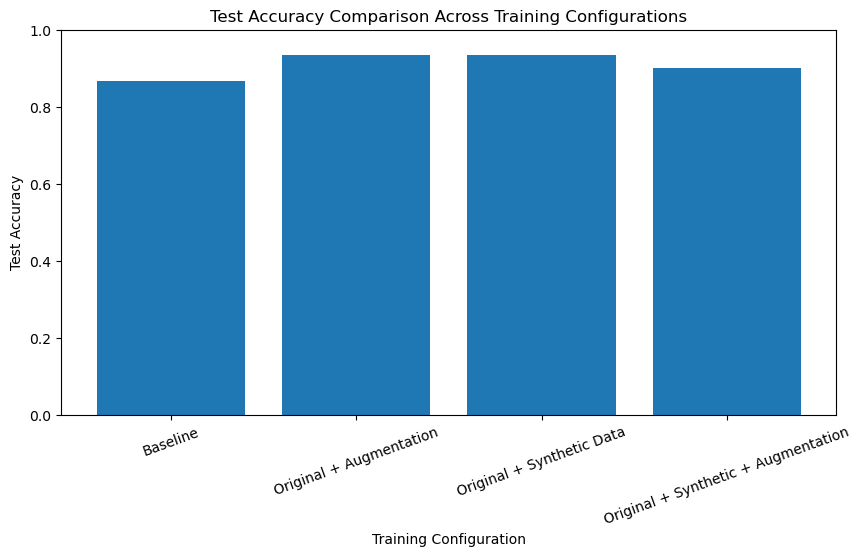

In [168]:
plt.figure(figsize=(10, 5))
plt.bar(df_results["Configuration"], df_results["Test Accuracy"])
plt.title("Test Accuracy Comparison Across Training Configurations")
plt.xlabel("Training Configuration")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

In [169]:
df_sorted = df_results.sort_values(by="Test Accuracy", ascending=False)

best_config = df_sorted.iloc[0]["Configuration"]
best_accuracy = df_sorted.iloc[0]["Test Accuracy"]

print("Best Performing Configuration:", best_config)
print("Best Test Accuracy:", best_accuracy)

if best_config == "Baseline":
    comparison_config = df_sorted.iloc[1]["Configuration"]
    comparison_accuracy = df_sorted.iloc[1]["Test Accuracy"]

    print("Baseline is the best model.")
    print("For focused analysis, comparing Baseline with second-best configuration:")
    print("Second-best Configuration:", comparison_config)
    print("Second-best Test Accuracy:", comparison_accuracy)
else:
    comparison_config = best_config
    comparison_accuracy = best_accuracy

    print("For focused analysis, comparing Baseline with Best Model:")
    print("Best Configuration:", comparison_config)
    print("Best Test Accuracy:", comparison_accuracy)

Best Performing Configuration: Original + Augmentation
Best Test Accuracy: 0.9333333333333333
For focused analysis, comparing Baseline with Best Model:
Best Configuration: Original + Augmentation
Best Test Accuracy: 0.9333333333333333


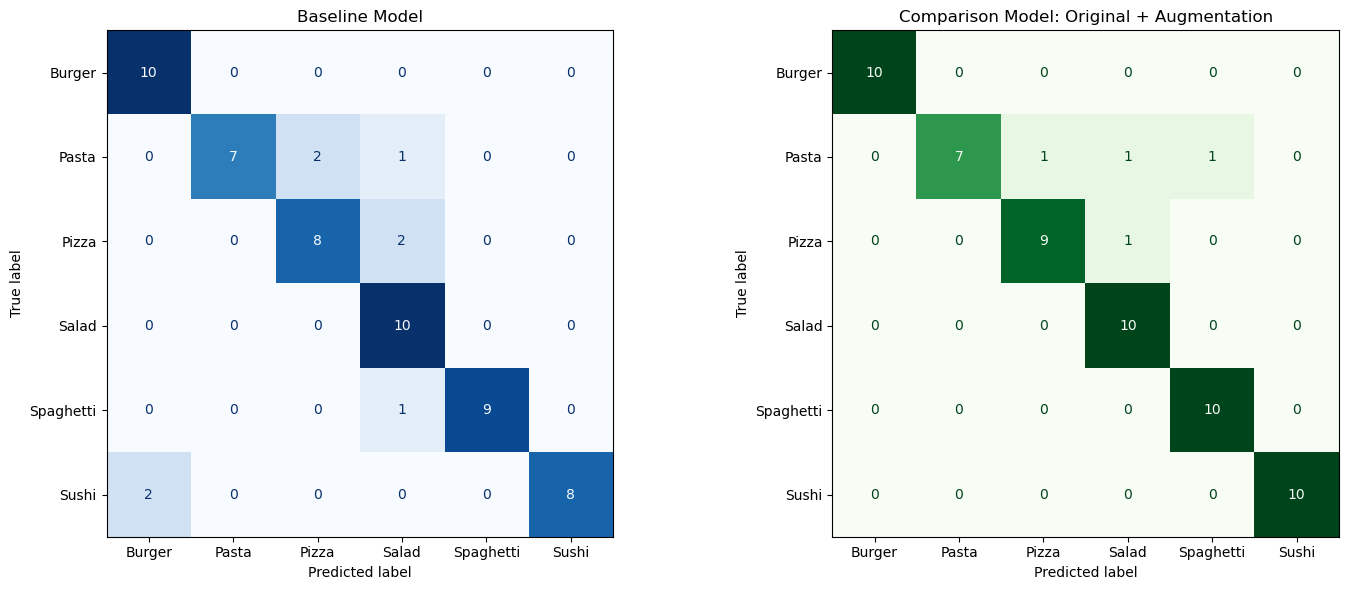

In [170]:
if comparison_config == "Baseline":
    comparison_preds = baseline_preds
    comparison_labels = baseline_labels
elif comparison_config == "Original + Augmentation":
    comparison_preds = aug_preds
    comparison_labels = aug_labels
elif comparison_config == "Original + Synthetic Data":
    comparison_preds = syn_preds
    comparison_labels = syn_labels
else:
    comparison_preds = combined_preds
    comparison_labels = combined_labels

class_names = test_data.classes

baseline_cm = confusion_matrix(baseline_labels, baseline_preds)
comparison_cm = confusion_matrix(comparison_labels, comparison_preds)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

disp1 = ConfusionMatrixDisplay(
    confusion_matrix=baseline_cm,
    display_labels=class_names
)
disp1.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Baseline Model")

disp2 = ConfusionMatrixDisplay(
    confusion_matrix=comparison_cm,
    display_labels=class_names
)
disp2.plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title(f"Comparison Model: {comparison_config}")

plt.tight_layout()
plt.show()

In [145]:
# -----------------------------
# ERROR ANALYSIS
# -----------------------------
import pandas as pd
import torch
import torch.nn as nn
from torchvision import models

def create_model():
    model = models.efficientnet_b0(pretrained=True)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 6)
    model = model.to(device)
    return model


def collect_misclassified_examples(model_path, model_name):
    model = create_model()
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    misclassified = []
    image_index = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)
            confidences, preds = torch.max(probabilities, 1)

            for i in range(len(labels)):
                true_label = labels[i].item()
                pred_label = preds[i].item()

                if pred_label != true_label:
                    misclassified.append({
                        "Model": model_name,
                        "Test Image Index": image_index,
                        "True Class": test_data.classes[true_label],
                        "Predicted Class": test_data.classes[pred_label],
                        "Confidence": round(confidences[i].item(), 4)
                    })

                image_index += 1

    return pd.DataFrame(misclassified)


# Baseline errors
baseline_error_df = collect_misclassified_examples(
    "best_model.pth",
    "Baseline"
)

# Best model errors
best_error_df = collect_misclassified_examples(
    best_model_path,
    best_config
)

print("Baseline Misclassified Examples:")
display(baseline_error_df)

print("\nBest Model Misclassified Examples:")
display(best_error_df)

c:\Users\swapn\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\swapn\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\swapn\AppData\Local\Temp\ipykernel_12228\976524492.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/bl

Baseline Misclassified Examples:


,Model,Test Image Index,True Class,Predicted Class,Confidence
0,Baseline,10,Pasta,Pizza,0.9911
1,Baseline,16,Pasta,Pizza,0.6647
2,Baseline,17,Pasta,Salad,0.9987
3,Baseline,27,Pizza,Salad,0.8375
4,Baseline,28,Pizza,Salad,0.6324
5,Baseline,46,Spaghetti,Salad,0.9254
6,Baseline,56,Sushi,Burger,0.9603
7,Baseline,59,Sushi,Burger,0.6672



Best Model Misclassified Examples:


,Model,Test Image Index,True Class,Predicted Class,Confidence
0,Original + Augmentation,12,Pasta,Spaghetti,0.4479
1,Original + Augmentation,16,Pasta,Pizza,0.3043
2,Original + Augmentation,17,Pasta,Salad,0.8311
3,Original + Augmentation,27,Pizza,Salad,0.5576


In [146]:
# -----------------------------
# ERROR COUNT BY TRUE CLASS
# -----------------------------
baseline_error_counts = baseline_error_df["True Class"].value_counts()
best_error_counts = best_error_df["True Class"].value_counts()

error_summary = pd.DataFrame({
    "Baseline Errors": baseline_error_counts,
    "Best Model Errors": best_error_counts
}).fillna(0).astype(int)

print("Error Summary by True Class:")
display(error_summary)

Error Summary by True Class:


,Baseline Errors,Best Model Errors
True Class,,
Pasta,3,3
Pizza,2,1
Spaghetti,1,0
Sushi,2,0


# Robustness

In [135]:
# -----------------------------
# Automatically select best model
# -----------------------------
model_paths = {
    "Baseline": "best_model.pth",
    "Original + Augmentation": "best_model_aug.pth",
    "Original + Synthetic Data": "best_model_syn.pth",
    "Original + Synthetic + Augmentation": "best_model_combined.pth"
}

accuracy_dict = {
    "Baseline": baseline_accuracy,
    "Original + Augmentation": augmentation_accuracy,
    "Original + Synthetic Data": synthetic_accuracy,
    "Original + Synthetic + Augmentation": combined_accuracy
}

best_config = max(accuracy_dict, key=accuracy_dict.get)
best_model_path = model_paths[best_config]

print("Best Model Selected for Robustness Testing:", best_config)
print("Best Model Path:", best_model_path)
print("Best Test Accuracy:", accuracy_dict[best_config])

Best Model Selected for Robustness Testing: Original + Augmentation
Best Model Path: best_model_aug.pth
Best Test Accuracy: 0.9333333333333333


In [136]:
# -----------------------------
# Load best model
# -----------------------------
model = models.efficientnet_b0(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 6)
model = model.to(device)

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

c:\Users\swapn\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\swapn\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\swapn\AppData\Local\Temp\ipykernel_12228\770685499.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blo

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [141]:
from torchvision.transforms import GaussianBlur

def add_noise(image):
    image = image.clone()
    noise = torch.randn_like(image) * 0.1
    return torch.clamp(image + noise, 0, 1)

blur = GaussianBlur(kernel_size=5)

def add_blur(image):
    image = image.clone()
    return blur(image)

def add_occlusion(image):
    image = image.clone()
    _, h, w = image.shape
    image[:, h//4:h//2, w//4:w//2] = 0
    return image

def change_brightness(image):
    image = image.clone()
    return torch.clamp(image * 1.5, 0, 1)

In [142]:
def evaluate_with_perturbation(perturb_fn=None):
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            if perturb_fn:
                images = torch.stack([perturb_fn(img) for img in images])
                images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = sum(
        [1 for i in range(len(all_preds)) if all_preds[i] == all_labels[i]]
    ) / len(all_labels)

    return accuracy

In [143]:
clean_acc = evaluate_with_perturbation()
noise_acc = evaluate_with_perturbation(add_noise)
blur_acc = evaluate_with_perturbation(add_blur)
occlusion_acc = evaluate_with_perturbation(add_occlusion)
lighting_acc = evaluate_with_perturbation(change_brightness)

df_robust = pd.DataFrame({
    "Condition": ["Clean", "Noise", "Blur", "Occlusion", "Lighting"],
    "Accuracy": [clean_acc, noise_acc, blur_acc, occlusion_acc, lighting_acc]
})

print(df_robust)

   Condition  Accuracy
0      Clean  0.933333
1      Noise  0.683333
2       Blur  0.900000
3  Occlusion  0.916667
4   Lighting  0.550000


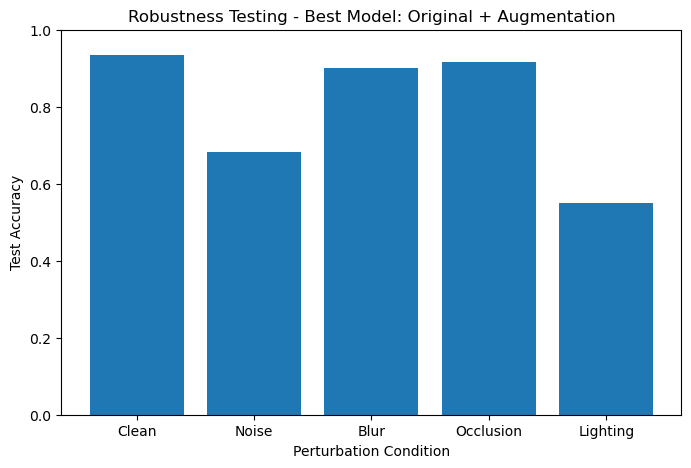

In [144]:
plt.figure(figsize=(8, 5))
plt.bar(df_robust["Condition"], df_robust["Accuracy"])
plt.title(f"Robustness Testing - Best Model: {best_config}")
plt.xlabel("Perturbation Condition")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.show()